# Conditional Multi-Channel Training ("PNN") — 1l2tau + 2l2tau Combined, Run 2 + Run 3 (Combined)

**Terminology check first, because it changes what's allowed here.** The
original parameterized NN (Baldi, Cranmer, Faucett, Gross & Whiteson, 2016)
conditions on a **physics** parameter - canonically a resonance mass - so
that one network `f(x, θ)` stands in for many mass-specific networks, and
because θ is continuous the network *interpolates* to mass points never
trained on. The defining trick is that background has no meaningful θ, so
θ is drawn randomly from signal's distribution for background events -
otherwise the network just learns "θ has a sensible value ⟹ signal" and
collapses.

**Channel is not that kind of parameter.** It's a real, observed property
of every event - signal, background, and (eventually) data alike. An event
genuinely has one lepton or two; there's no "channel 1.5" to interpolate
to. So:
- `is_1l2tau`/`is_2l2tau` are **never randomized for background** - that
  trick only applies to parameters that exist for signal and are undefined
  for background. Getting this backwards is the most common way to break
  this technique.
- There is **no interpolation** happening here.

People in ATLAS/CMS still call this a "PNN" and this notebook keeps that
name for continuity with the sibling model notebooks, but mechanically it's
**conditional multi-channel training**: one shared network sees both
channels' events with a channel indicator as an extra input, for reasons
like shared feature learning, more effective statistics for the common
physics, and one model to maintain instead of several - not for
interpolation. (If a resonant X→HH search with multiple m_X points ever
enters this analysis, that WOULD be a genuine PNN axis - randomized for
background, interpolatable - layered on top of the channel/era flags below,
which stay real and non-randomized. The code here is structured so adding
that later is a straightforward extra column, not a rewrite.)

## Encoding: one-hot, not ordinal

`is_1l2tau`/`is_2l2tau` are **two** columns (one-hot), not a single ordinal
0/1 column. With exactly two channels today a single binary column *is*
already a one-hot for two categories - it barely matters yet. But
HH-multilepton has more sub-channels (2lSS, 2lSS+1τ, 3l, ...), and the
moment a third one appears, an ordinal `channel ∈ {0,1,2}` would tell the
network channel 2 is "twice as far" from channel 0 as channel 1 is, which
is meaningless. Starting one-hot means never having to revisit this.

**Note:** the project's `is_feature()` leakage policy blocks
`hhml_subchannelflavor` as a leakage risk. `is_1l2tau`/`is_2l2tau` are, in
spirit, a reintroduction of exactly that kind of information. This is
**deliberate and intended** here (conditioning on channel is the whole
point of this notebook) - NOT a leakage bug, so please don't "fix" it by
re-blocking these columns later.

## The real hard part: reconciling the feature schemas

1l2tau gives `l1`, `τ1`, `τ2`. 2l2tau gives `l1`, `l2`, `τ1`, `τ2` - so
`m_l1l2`/`dR_l1l2`/etc. exist only in 2l2tau. Taking the plain
**intersection** of leakage-free features (what `discover_common_features`
already does per-channel) silently throws away exactly the second-lepton
variables that make 2l2tau powerful. Three options, increasing effort:

1. **Intersection only** (what this notebook does). Loses real
   discriminating power, but is the right first version to prove the
   plumbing works.
2. **Union + sentinel + presence flags.** Keep every column; where a
   variable is undefined for a channel, fill a fixed out-of-range value
   plus an `is_defined` companion flag, and fit imputation/scaling
   PER CHANNEL (a global median/scaler would smear together two different
   channel-specific distributions).
3. **Generic object slots** (lep1, lep2-or-absent, tau1, tau2, ...) with
   type flags, so a column means the same thing everywhere - the natural
   on-ramp to DeepSets/particle-transformer architectures.

**Suggested order (this notebook = step 1):** intersection features +
channel one-hot + per-cell weights, evaluated per channel against the solo
baselines. If that holds, move to union features with presence flags.
Worry about conditioning depth (input-concat vs. per-layer vs. FiLM) last.

## Weighting: per-cell, not global

A global `make_fit_weights` balances signal vs. background over the WHOLE
pooled sample. Pool two channels (or eras) with very different event
counts and the loss gets dominated by whichever cell has the most MC
events - and, more subtly, the network ends up learning
`p(signal | x, channel)` INCLUDING the prior `p(signal | channel)` implied
by the weights, so its output baseline silently shifts per channel (a cut
at 0.9 would mean something different in each channel). This notebook
balances signal vs. background WITHIN each `(channel × run × class)` cell
first, then mean-normalizes globally - see `make_fit_weights(...,
cell_ids=...)` below. Run2 and Run3 have different MC statistics per
process too, so now that both are combined the same cell-weighting logic
is applied jointly across `channel` and `run`, not just `channel`.

## Evaluation: pooled AUC will lie

If one channel is intrinsically cleaner, pooling raises the headline AUC
even if the model got WORSE in the other channel. This notebook always
reports **per-channel** AUC/Z first, and the "Comparison Against
Solo-Channel Baselines" section near the end checks the only comparison
that actually matters: does the combined model beat each channel's OWN
solo-trained models (XGBoost/MLP/DNN/GNN) IN THAT CHANNEL. AUC also isn't
the endpoint - HH is at S/B ≈ 1.3×10⁻⁴ preselection-level, so the real
figure of merit is expected significance from a binned fit in the high-score
tail, reported here via the Asimov-Z scan (per channel too).

## Scope of this pass

Run 2 **and** Run 3, combined per channel first (`load_combined_run` -
own `discover_common_features`/`load_run_data`/`clean_data` per run, then
intersected on features with a `run` tag, mirroring the Run2+Run3
"Combined" track used by `DNN.ipynb`/`GNN_Evie.ipynb`), and THEN the two
channels' Combined samples are combined on top of that, exactly as before.
Every stratification/weighting step that already existed for `channel`
(train/val/test split strata, per-cell signal/background balancing) is now
extended to `channel` × `run` jointly, since Run2 and Run3 have different
MC statistics per process - the same imbalance risk the "Weighting"
section above already warns about for channels, now doubled for runs.

**Correlation pruning / top-15 stage:** now included (see "Correlation
Pruning & Retraining" below), mirroring the XGBoost master pipeline and the
solo MLP/DNN/GNN notebooks' full → pruned (top-20) → top-15 ladder, so the
"Comparison Against Solo-Channel Baselines" section compares this
notebook's final model against each solo model's own final (top-15) model
on the same footing. The one exception: `is_1l2tau`/`is_2l2tau` are
**excluded from the importance-ranking/pruning candidate pool** and
**unconditionally re-appended** to every pruned/top-15 feature set - they
are the entire point of this notebook, not a redundant physics input, so a
generic correlation-pruning walk must never be allowed to drop them just
because they didn't rank in the top 30 by permutation importance.



## Libraries

In [18]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    Determinism is only guaranteed on the SAME machine / CUDA / torch
    version - it is not portable across hardware or library versions.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ---------------------------------------------------------------------------
# Paths - BOTH channels, Run 2 AND Run 3 (each channel is combined into its
# own Run2+Run3 "Combined" sample first - see "Load Both Channels" below -
# and THEN the two channels are combined into one PNN training sample; see
# intro markdown). Each channel keeps its own base dirs/preselection/
# leakage-blocklist - they are only combined AFTER independent
# discover/load/clean, in the "PNN Parameter: Channel" section below.
# ---------------------------------------------------------------------------

BASE_DIR_1L2TAU_RUN2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_1L2TAU_RUN3 = Path("PPSSP_2026/1l2tau/run3")
BASE_DIR_2L2TAU_RUN2 = Path("PPSSP_2026/2l2tau/run2")
BASE_DIR_2L2TAU_RUN3 = Path("PPSSP_2026/2l2tau/run3")
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselections (see repo README.md) - differ per channel.
# ---------------------------------------------------------------------------

PRESELECTION_1L2TAU = "(n_b_jet == 0) & (n_jet >= 2)"
PRESELECTION_2L2TAU = "(n_b_jet == 0) & (l1_charge * l2_charge < 0) & (mZ_cut > 0)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background) - same file names
# in both channels' directories.
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy - BLOCK_SUBSTR is shared, but
# BLOCK_EXACT differs per channel (each has its own preselection-flag/
# pair-flag branch names, and 2l2tau has extra always-constant-post-cut
# branches). Identical to 1L2Tau_Master_Pipeline.ipynb /
# 2L2Tau_Master_Pipeline.ipynb.
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]

BLOCK_EXACT_1L2TAU = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig",
    "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode",
    "tau1_nprong", "tau2_nprong",
}

BLOCK_EXACT_2L2TAU = {
    "n_b_jet", "pass2l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSlep1lep2", "tau2_baseline_RNNTight", "l1_d0sig",
    "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode",
    "tau1_nprong", "tau2_nprong", "mZ_cut", "mZreq", "low_mass_cut", "xgb_score",
}


def make_is_feature(block_exact):

    """Returns an `is_feature(branch)` predicate closed over `block_exact`
    (each channel has its own exact-match blocklist; BLOCK_SUBSTR is shared)."""

    block_exact_lower = {b.lower() for b in block_exact}

    def is_feature(branch):
        lb = branch.lower()
        return lb not in block_exact_lower and not any(s.lower() in lb for s in BLOCK_SUBSTR)

    return is_feature


IS_FEATURE_1L2TAU = make_is_feature(BLOCK_EXACT_1L2TAU)
IS_FEATURE_2L2TAU = make_is_feature(BLOCK_EXACT_2L2TAU)


## Data Loading Helpers

In [ ]:
def discover_common_features(base_dir, is_feature, files=FILES, tree_name=TREE_NAME):

    """
    Branches common to EVERY process file in `base_dir`, filtered through
    the given `is_feature` predicate (channel-specific - see Paths cell).
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, preselection, files=FILES, weight_parts=WEIGHT_PARTS,
                   tree_name=TREE_NAME, verbose=True):

    """
    Read every process file under `base_dir`, apply `preselection` at read
    time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] = df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)

    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features


def load_combined_run(base_dir_run2, base_dir_run3, is_feature, preselection,
                       files=FILES, tree_name=TREE_NAME, label=""):

    """
    Loads Run 2 and Run 3 independently (own discover_common_features/
    load_run_data/clean_data each), then concatenates on the INTERSECTION of
    the two runs' leakage-free feature sets with a `run` tag (2 or 3),
    re-cleaning the combined result - the same Run2+Run3 "Combined" track
    pattern `DNN.ipynb`/`GNN_Evie.ipynb` use, applied here per channel BEFORE
    the two channels are themselves combined (see "Conditioning Variable:
    Channel" below). `label` is only used for print statements.
    """

    print(f"--- {label} Run 2 ---")
    candidate_features_run2 = discover_common_features(base_dir_run2, is_feature, files, tree_name)
    data_run2 = load_run_data(base_dir_run2, candidate_features_run2, preselection, files, tree_name=tree_name)
    data_run2, features_run2 = clean_data(data_run2, candidate_features_run2)

    print(f"\n--- {label} Run 3 ---")
    candidate_features_run3 = discover_common_features(base_dir_run3, is_feature, files, tree_name)
    data_run3 = load_run_data(base_dir_run3, candidate_features_run3, preselection, files, tree_name=tree_name)
    data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)

    common_features = sorted(set(features_run2) & set(features_run3))
    keep_cols = common_features + ["w_phys", "label", "process"]

    d2 = data_run2[keep_cols].copy(); d2["run"] = 2
    d3 = data_run3[keep_cols].copy(); d3["run"] = 3

    data_combined, features_combined = clean_data(pd.concat([d2, d3], ignore_index=True), common_features)

    print(f"\n{label} Combined (Run2+Run3): {len(data_combined)} events, {len(features_combined)} features "
          f"(Run2 alone had {len(features_run2)}, Run3 alone had {len(features_run3)})")

    return data_combined, features_combined


## Load Both Channels (Run 2 + Run 3 → Combined)

Each channel is combined across Run 2 + Run 3 first (`load_combined_run` -
own discover/load/clean per run, then intersected on features with a `run`
tag, the same Run2+Run3 "Combined" track pattern used elsewhere),
independently of the other channel (own base dirs, own preselection, own
leakage blocklist) - the two channels are only combined in the next
section, once each channel's own leakage-free Combined feature list is
known.



In [ ]:
data_1l2tau, features_1l2tau = load_combined_run(
    BASE_DIR_1L2TAU_RUN2, BASE_DIR_1L2TAU_RUN3, IS_FEATURE_1L2TAU, PRESELECTION_1L2TAU, label="1l2tau",
)

print()

data_2l2tau, features_2l2tau = load_combined_run(
    BASE_DIR_2L2TAU_RUN2, BASE_DIR_2L2TAU_RUN3, IS_FEATURE_2L2TAU, PRESELECTION_2L2TAU, label="2l2tau",
)


81 candidate features (common to all 10 processes, leakage-free)


signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection
Dropped 17 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_passOR']

64 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | background = 11467.29

85 candidate features (common to all 10 processes, leakage-free)
signal_ggF

## Conditioning Variable: Channel (One-Hot)

`is_1l2tau`/`is_2l2tau` are new *engineered* input columns, not physics
branches - they are added directly to the combined `data`, added to the
model's input, and deliberately kept out of `features` (so the leakage
blocklist / sentinel audit / correlation-pruning-style machinery never
touches them, they're always available to the network).

- `is_1l2tau=1, is_2l2tau=0` for every 1l2tau event; `is_1l2tau=0,
  is_2l2tau=1` for every 2l2tau event - this is a REAL, deterministic
  property of every row (signal AND background). Unlike a genuine PNN
  parameter (e.g. a resonance mass, meaningless for background and so
  randomized there), channel is observed for every event - **no
  randomization trick is applied or needed here**.
- One-hot (two columns), not a single ordinal column - see the intro
  markdown for why (future-proofs against a third sub-channel later).
- The model's physics input is restricted to the features **common to both
  channels** (the intersection of each channel's own leakage-free feature
  list) - a channel-specific column like 2l2tau's `l2_pt` or 1l2tau's
  `n_tau` simply doesn't exist for rows from the other channel, so it can't
  be fed to a single shared network. See the intro markdown's "reconciling
  the feature schemas" section for the staged plan to recover this
  information later (union + presence flags).

At inference, fixing `is_1l2tau`/`is_2l2tau` to a chosen one-hot vector for
every event lets the same trained network stand in for a
"1l2tau-conditioned" or "2l2tau-conditioned" classifier - validated (with a
direct sensitivity pre-check too) in the "Parameterized Inference
Validation" section near the end.


In [22]:
def combine_channels(data_1l2tau, data_2l2tau, features_1l2tau, features_2l2tau):

    """
    Restricts each channel's DataFrame to the leakage-free features COMMON
    to both channels (so every row shares the same column schema - the
    deliberate "intersection-only" first-pass choice, see intro markdown),
    tags each with a ONE-HOT channel encoding (`is_1l2tau`, `is_2l2tau`)
    plus a readable `channel` label, then concatenates.

    One-hot, not a single ordinal 0/1 column: with only two channels today
    a single column would behave identically, but HH-multilepton has more
    sub-channels (2lSS, 2lSS+1tau, 3l, ...) - the moment a third channel
    appears, an ordinal encoding (0/1/2) would falsely imply channel 2 is
    "twice as far" from channel 0 as channel 1 is. One-hot from the start
    means never having to revisit this.

    NOTE: this is conceptually close to reintroducing the blocked
    `hhml_subchannelflavor` branch (see BLOCK_EXACT_* above). That is
    DELIBERATE and INTENDED here - conditioning on channel is the whole
    point of this notebook, NOT a leakage bug. Please don't "fix" it by
    re-blocking `is_1l2tau`/`is_2l2tau` later.

    Returns (data, common_features); `common_features` excludes the
    one-hot columns / `channel` / bookkeeping columns, matching the
    `features` convention used elsewhere.
    """

    common_features = sorted(set(features_1l2tau) & set(features_2l2tau))
    keep_cols = common_features + ["w_phys", "label", "process"]

    d1 = data_1l2tau[keep_cols].copy()
    d1["is_1l2tau"] = 1.0
    d1["is_2l2tau"] = 0.0
    d1["channel"] = "1l2tau"

    d2 = data_2l2tau[keep_cols].copy()
    d2["is_1l2tau"] = 0.0
    d2["is_2l2tau"] = 1.0
    d2["channel"] = "2l2tau"

    data = pd.concat([d1, d2], ignore_index=True)

    print(f"{len(common_features)} features common to both channels "
          f"(1l2tau had {len(features_1l2tau)}, 2l2tau had {len(features_2l2tau)})")
    print(f"Channel mix: 1l2tau = {len(d1)} events (is_1l2tau=1, is_2l2tau=0), "
          f"2l2tau = {len(d2)} events (is_1l2tau=0, is_2l2tau=1)")

    return data, common_features


data_raw, common_features = combine_channels(data_1l2tau, data_2l2tau, features_1l2tau, features_2l2tau)

# Re-run clean_data on the COMBINED sample: a feature that varied within
# each channel individually could still end up constant now, or vice versa
# (unlikely) - same defensive re-check as the Run2+Run3 "Combined" tracks in
# DNN.ipynb/GNN_Evie.ipynb use after concatenating.
data, features = clean_data(data_raw, common_features)


61 features common to both channels (1l2tau had 64, 2l2tau had 79)
Channel mix: 1l2tau = 690684 events (is_1l2tau=1, is_2l2tau=0), 2l2tau = 94968 events (is_1l2tau=0, is_2l2tau=1)


Dropped 0 constant/empty features:
  []

61 final features
Total: 785652 events | signal = 126271 | background = 659381
Yield (w_phys): signal = 2.24 | background = 12501.44


## Sentinel Audit (-1)

`clean_data` only masks `< -100` sentinels (e.g. `-999`) to NaN. Some ATLAS
branches instead default to exactly `-1` for "undefined", which `clean_data`
would otherwise treat as a legitimate physical value. `-1` is also a
perfectly valid value for plenty of other branches (e.g. charges), so it
must **not** be blanket-masked - only branches where `-1` is a genuine
"undefined" sentinel (a spike at `-1` detached from the rest of the
distribution, with a gap just above it) should be added to
`NEG1_SENTINEL_FEATURES` below. The diagnostic cell prints, per feature, the
fraction of rows exactly equal to `-1` and the gap to the next-smallest
value above `-1`, to help build that set by inspection - it does not decide
automatically.

In [23]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []

for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

# Apply the (currently empty) mask before the train/val/test split, so any
# features added to NEG1_SENTINEL_FEATURES later automatically flow into
# both the median-imputation and the missingness flags below.

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)
    
if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

1 / 61 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.477764                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing

Deterministic two-stage stratified **80/10/10** train/val/test split
(`make_3way_split`), stratified on `label` **and** `channel` jointly
(`extra_stratify_col="channel"`) so the 1l2tau/2l2tau mix stays balanced
across train/val/test - the same pattern `DNN.ipynb`/`GNN_Evie.ipynb` use
for their Run2+Run3 "Combined" track (`extra_stratify_col="run"`), just
combining channels instead of runs here. This combined-channel sample has a
different row set/schema than any single-channel notebook's test
partition, so there's nothing to cross-check against yet - the test
partition is still persisted (to its own dedicated `splits/` dir) for
reproducibility, and `assert_same_test_partition` will simply report
"nothing to check" until/unless another notebook shares this exact combined
schema.

The one-hot `is_1l2tau`/`is_2l2tau` columns ride along as ordinary columns
of `data`/`train_df`/`val_df`/`test_df` (added before the split) and are
appended **unscaled** (already 0/1) right after the scaled physics features
- `MODEL_FEATURES = features + channel_cols` is the canonical name list for
the model's input columns.

Neural nets (unlike XGBoost) can't handle NaN natively, so sentinel-masked
physics values are median-imputed (fit on the train split only) before
standard scaling; missingness itself is preserved via `__isnan` flag
columns (schema derived from train only, also unscaled). Training weights
are balanced **per `(channel × class)` cell first, then mean-normalized
globally** (`make_fit_weights(..., cell_ids=channel_train)` - see the intro
markdown's "Weighting" section for why a plain global balance would be
wrong here); validation/test weights stay as plain `|w_phys|`. Per the
supervisor's project-wide policy, negative-`w_phys` training events are
dropped entirely (not abs'd) before fitting.


In [24]:
def make_fit_weights(labels, abs_weights, cell_ids=None):

    """
    Balance signal/background total weight and normalize the OVERALL mean
    weight to 1. If `cell_ids` is given (e.g. the `channel` column), the
    signal/background balance is computed WITHIN each distinct cell_id
    value FIRST, before the global mean-normalization - this stops
    whichever cell has the most MC events (e.g. one channel, or one run
    era) from dominating the pooled loss, and keeps each cell's own
    signal/background ratio meaningful (the network learns "how
    signal-like within its own cell", not a mix skewed by cross-cell event
    counts - see the intro markdown's "Weighting" section). If `cell_ids`
    is None, balances signal/background globally only (single-cell
    behavior). `abs_weights` must already be non-negative (Sherpa weights
    can be negative).
    """

    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()

    if cell_ids is None:
        sum_signal = fit_weights[labels == 1].sum()
        sum_background = fit_weights[labels == 0].sum()
        fit_weights[labels == 1] *= sum_background / sum_signal
    else:
        cell_ids = np.asarray(cell_ids)
        for cell in np.unique(cell_ids):
            m = cell_ids == cell
            sum_signal = fit_weights[m & (labels == 1)].sum()
            sum_background = fit_weights[m & (labels == 0)].sum()
            if sum_signal > 0:
                fit_weights[m & (labels == 1)] *= sum_background / sum_signal

    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def make_3way_split(data, test_size=0.10, val_size=0.10, seed=RANDOM_STATE, extra_stratify_col=None):

    """
    Deterministic two-stage stratified 80/10/10 train/val/test split - same
    logic/seed as DNN.ipynb/1L2Tau_Master_Pipeline.ipynb's make_3way_split.
    Called here with `extra_stratify_col="channel"` so the 1l2tau/2l2tau mix
    is stratified alongside `label`, matching the pattern used for the
    Run2+Run3 "Combined" tracks elsewhere (`extra_stratify_col="run"`).

    TEST must not participate in anything until it is scored exactly once at
    the very end: not the median imputation, not the StandardScaler fit,
    not `flag_cols`, not early stopping, not the significance-scan score-cut
    selection.

    Stage 1 peels off `test_size` (10%) as TEST. Stage 2 splits the
    remaining (1 - test_size) into train/val; to get `val_size` (10%) OF THE
    FULL SAMPLE, stage 2's test_size must be val_size / (1 - test_size) =
    0.10 / 0.90 = 1/9, NOT val_size itself.
    """

    def _strata(df):
        if extra_stratify_col is not None:
            return df["label"].astype(str) + "_" + df[extra_stratify_col].astype(str)
        return df["label"]

    trainval_df, test_df = train_test_split(data, test_size=test_size, random_state=seed, stratify=_strata(data))

    val_frac_of_remaining = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        trainval_df, test_size=val_frac_of_remaining, random_state=seed, stratify=_strata(trainval_df)
    )

    for name, df in (("Train", train_df), ("Val", val_df), ("Test", test_df)):
        sig_n, bkg_n = int((df.label == 1).sum()), int((df.label == 0).sum())
        sig_y = df.loc[df.label == 1, "w_phys"].sum()
        bkg_y = df.loc[df.label == 0, "w_phys"].sum()
        print(f"{name:5s}: {len(df):>8d} events | signal = {sig_n:>7d} (yield={sig_y:>10.2f}) | "
              f"background = {bkg_n:>7d} (yield={bkg_y:>10.2f}) | "
              f"signal weight scale factor = {bkg_y / sig_y:.1f}")

    return train_df, val_df, test_df


def assert_same_test_partition(test_df, path):

    """
    Cross-notebook guard: if a test partition already exists on disk at
    `path`, verify this notebook's freshly-computed `test_df` is equal to
    it on their shared columns. For this channel-combined schema no sibling
    notebook writes to `SPLIT_DIR_COMBINED` yet, so this currently just
    documents the convention (and would catch drift on a future re-run of
    THIS notebook).
    """

    path = Path(path)
    if not path.exists():
        print(f"  (no prior test partition at {path} yet - nothing to cross-check)")
        return

    prior_df = uproot.open({str(path): "tree"}).arrays(library="pd")
    cols = sorted((set(test_df.columns) & set(prior_df.columns)) - {"run"})
    a = test_df[cols].sort_values(cols).reset_index(drop=True)
    b = prior_df[cols].sort_values(cols).reset_index(drop=True)

    pd.testing.assert_frame_equal(a, b, check_exact=False, rtol=1e-5, atol=1e-8, check_dtype=False)
    print(f"  cross-check OK: {path} test partition matches on {len(cols)} shared columns ({len(test_df)} rows)")


def persist_test_partition(test_df, split_dir):

    """Persist just TEST to disk under `split_dir`, cross-checking against
    any prior test.root there first."""

    split_dir = Path(split_dir)
    split_dir.mkdir(parents=True, exist_ok=True)
    test_path = split_dir / "test.root"
    assert_same_test_partition(test_df, test_path)
    with uproot.recreate(test_path) as f:
        f["tree"] = test_df.reset_index(drop=True)
    print(f"Wrote {len(test_df)} test events -> {test_path}  (held out until final evaluation)")


train_df, val_df, test_df = make_3way_split(data, extra_stratify_col="channel")

BASE_DIR_COMBINED = Path("PPSSP_2026/pnn_channel_combined/run2")
SPLIT_DIR_COMBINED = BASE_DIR_COMBINED / "splits"
persist_test_partition(test_df, SPLIT_DIR_COMBINED)


Train:   628520 events | signal =  101017 (yield=      1.79) | background =  527503 (yield=   9929.35) | signal weight scale factor = 5542.6
Val  :    78566 events | signal =   12627 (yield=      0.22) | background =   65939 (yield=   1314.95) | signal weight scale factor = 5954.8
Test :    78566 events | signal =   12627 (yield=      0.23) | background =   65939 (yield=   1257.15) | signal weight scale factor = 5496.0
  cross-check OK: PPSSP_2026/pnn_channel_combined/run2/splits/test.root test partition matches on 65 shared columns (78566 rows)
Wrote 78566 test events -> PPSSP_2026/pnn_channel_combined/run2/splits/test.root  (held out until final evaluation)


In [25]:
X_train_raw, y_train, w_train = train_df[features], train_df["label"].to_numpy(), train_df["w_phys"].to_numpy()
X_val_raw,   y_val,   w_val   = val_df[features],   val_df["label"].to_numpy(),   val_df["w_phys"].to_numpy()
X_test_raw,  y_test,  w_test  = test_df[features],  test_df["label"].to_numpy(),  test_df["w_phys"].to_numpy()

# One-hot channel conditioning columns (see combine_channels markdown for why
# one-hot over a single ordinal column).
channel_cols = ["is_1l2tau", "is_2l2tau"]
param_train = train_df[channel_cols].to_numpy(dtype=np.float32)
param_val = val_df[channel_cols].to_numpy(dtype=np.float32)
param_test = test_df[channel_cols].to_numpy(dtype=np.float32)

channel_train = train_df["channel"].to_numpy()  # per-cell weighting key, filtered below alongside w_train

# ---- Missingness indicator flags (schema derived from TRAIN only) ---------
nan_train = X_train_raw.isna()
flag_cols = nan_train.columns[nan_train.any()].tolist()


def make_flags(X_raw):
    """0/1 missingness flags for `flag_cols`, kept unscaled - scaling a 0/1
    flag would just relabel it, not add information."""
    f = X_raw[flag_cols].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols]
    return f


# Median imputation (fit on train only), then standard scaling (fit on train
# only). TEST is only ever transformed with these already-frozen train
# statistics, never used to fit them. The one-hot channel columns are
# stacked in RIGHT AFTER the scaled physics features (unscaled, already
# 0/1) - MODEL_FEATURES below is the canonical name list for those columns;
# any __isnan flags trail after and are simply not addressed by name.

train_medians = X_train_raw.median()
X_train_imp = X_train_raw.fillna(train_medians)
X_val_imp = X_val_raw.fillna(train_medians)
X_test_imp = X_test_raw.fillna(train_medians)

scaler = StandardScaler()
X_train_scaled = np.hstack([scaler.fit_transform(X_train_imp), param_train, make_flags(X_train_raw).to_numpy()])
X_val_scaled = np.hstack([scaler.transform(X_val_imp), param_val, make_flags(X_val_raw).to_numpy()])
X_test_scaled = np.hstack([scaler.transform(X_test_imp), param_test, make_flags(X_test_raw).to_numpy()])

MODEL_FEATURES = features + channel_cols

assert np.isfinite(X_train_scaled).all(), "NaN/inf reached the model input (train)"
assert np.isfinite(X_val_scaled).all(), "NaN/inf reached the model input (val)"
assert np.isfinite(X_test_scaled).all(), "NaN/inf reached the model input (test)"

print(f"\n{len(flag_cols)} features had missing values in train -> added {len(flag_cols)} __isnan flag "
      f"columns (final input width = {X_train_scaled.shape[1]} = {len(features)} features + "
      f"{len(channel_cols)} channel one-hot columns + {len(flag_cols)} flags)")

# Training weights: per the supervisor's project-wide policy, events with
# negative w_phys are DROPPED from the training set entirely (not
# abs'd/imputed). X_train_scaled already has param_train stacked in, so
# this filter keeps everything row-aligned automatically. Validation/test
# are untouched and still use |w_phys| for early stopping / AUC.

train_neg_mask = w_train < 0
n_dropped = int(train_neg_mask.sum())
print(f"Dropped {n_dropped}/{len(w_train)} negative-w_phys training events "
      f"({n_dropped / len(w_train):.1%}) - kept, not abs'd")

X_train_scaled = X_train_scaled[~train_neg_mask]
y_train = y_train[~train_neg_mask]
w_train = w_train[~train_neg_mask]  # already non-negative post-filter
channel_train = channel_train[~train_neg_mask]

# Per-CELL (channel x class) weight balancing, THEN global mean-normalization
# - NOT a plain global balance. A global-only balance would let whichever
# channel has the most training events dominate the pooled loss, and would
# bake that channel's background/signal MIX into the score as an implicit
# prior rather than letting the score mean "how signal-like within its own
# channel" - see the intro markdown's "Weighting" section for why that
# matters once the score is used to define fit categories.
w_train_fit = make_fit_weights(y_train, w_train, cell_ids=channel_train)
w_train_abs = w_train  # non-negative post-filter; eval-mode "comparable" train curves

# Validation weights for AUC: plain |w_phys| so AUC reflects the true class balance.
w_val_fit = np.abs(w_val)

# Test weights: plain |w_phys| too - test is only ever scored once, at the
# very end, so there is no "fit" version needed.
w_test_fit = np.abs(w_test)

for cell in ["1l2tau", "2l2tau"]:
    m = channel_train == cell
    print(f"Signal weight scale factor (train, post-filter, {cell} cell): "
          f"{w_train[m & (y_train==0)].sum() / w_train[m & (y_train==1)].sum():.1f}")



23 features had missing values in train -> added 23 __isnan flag columns (final input width = 86 = 61 features + 2 channel one-hot columns + 23 flags)
Dropped 66061/628520 negative-w_phys training events (10.5%) - kept, not abs'd
Signal weight scale factor (train, post-filter, 1l2tau cell): 7653.4
Signal weight scale factor (train, post-filter, 2l2tau cell): 2703.0


## PyTorch Dataset & Model (ParameterizedNN)

Architecturally this is an ordinary feed-forward binary classifier - the
"conditioning" comes entirely from the one-hot `is_1l2tau`/`is_2l2tau`
columns being two extra input dimensions concatenated at the input layer
(the standard first thing to try), not from any special layer or loss. If
the "Parameterized Inference Validation" section's sensitivity check later
shows the network barely responds to these two columns among ~70 inputs,
the next things to try are conditioning at every hidden layer or FiLM
(a small network mapping the flags to per-layer scale/shift) - not
attempted in this first pass. `hidden_sizes=(256, 128)` reuses the
architecture that already won a hidden-size grid search for the 1l2tau
Run 2 feature/data setup (see `MLP.ipynb`) - skipped here again for this
first, simpler pass.


In [26]:
# Model input is small enough to comfortably fit in GPU memory - keep it
# resident there for the whole run instead of using a DataLoader, which
# would otherwise copy every mini-batch host->device one at a time. Batches
# are then just GPU-side tensor indexing (see run_epoch).

BATCH_SIZE = 8192

DEFAULT_HIDDEN_SIZES = (256, 128)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
w_train_t = torch.tensor(w_train_fit, dtype=torch.float32, device=DEVICE)
w_train_abs_t = torch.tensor(w_train_abs, dtype=torch.float32, device=DEVICE)  # |w_phys|, dropout-off "eval-mode" train weights

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)
w_val_t = torch.tensor(w_val_fit, dtype=torch.float32, device=DEVICE)

# TEST is only ever read once, in the "Held-Out Test Evaluation" cell near
# the end - kept GPU-resident here purely for consistency with train/val.
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=DEVICE)
w_test_t = torch.tensor(w_test_fit, dtype=torch.float32, device=DEVICE)


class ParameterizedNN(nn.Module):

    """
    Mechanically an ordinary feed-forward binary classifier (hidden layers
    with ReLU + dropout, single output logit paired with
    BCEWithLogitsLoss) - the class name is kept for continuity with the
    sibling model notebooks, but this is conditional multi-channel
    training, not a true interpolating PNN (see intro markdown). Its input
    already includes the one-hot channel columns (`is_1l2tau`/`is_2l2tau`)
    as ordinary extra columns - there is nothing conditioning-specific in
    the architecture itself (input-concat only for this first pass).
    """

    def __init__(self, n_features, hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3):

        super().__init__()
        layers = []
        in_size = n_features

        for hidden_size in hidden_sizes:

            layers += [nn.Linear(in_size, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = hidden_size

        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, n_features=None):

    """
    Factory so a hyperparameter search (or a feature-subset retrain) can
    build a fresh model per trial without repeating the
    ParameterizedNN(...).to(DEVICE) boilerplate. `n_features` defaults to
    the full input width (physics features + one-hot channel columns +
    missingness flags).
    """

    if n_features is None:
        n_features = X_train_scaled.shape[1]
    return ParameterizedNN(n_features=n_features, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)


model = build_model()

print(model)


ParameterizedNN(
  (net): Sequential(
    (0): Linear(in_features=86, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy (per-sample weights folded in manually, since
`BCEWithLogitsLoss` has no built-in sample-weight argument), Adam optimizer,
early stopping on weighted validation AUC.

In [27]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over the GPU-resident tensors (X, y, w), split into
    `batch_size` chunks via plain tensor indexing (no DataLoader). Loss/
    predictions are only pulled to the CPU once, at the very end of the
    epoch, instead of calling `.item()`/`.cpu()` inside the loop (which
    would force a CPU<->GPU sync every mini-batch and stall the GPU).
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb, wb = X[idx], y[idx], w[idx]

            logits = model(xb)
            loss = (criterion(logits, yb) * wb).sum() / wb.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.detach() * wb.sum()
            total_weight += wb.sum()
            all_labels.append(yb.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(wb.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()

    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, lr=LEARNING_RATE,
                 n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 X_train_data=None, y_train_data=None, w_train_data=None,
                 X_val_data=None, y_val_data=None, w_val_data=None,
                 w_train_eval_data=None):

    """
    Build a fresh ParameterizedNN(hidden_sizes, dropout) and train it with
    early stopping on weighted validation AUC. Data args default to the
    full-input GPU-resident tensors (X_train_t/y_train_t/w_train_t/
    X_val_t/y_val_t/w_val_t).

    Every epoch also runs an EVAL-MODE pass over the training data (dropout
    off, plain |w_phys| weights via `w_train_eval_data`, default
    `w_train_abs_t`) - "train_auc_eval"/"train_loss_eval" are directly
    comparable to the val curve (dropout off, |w_phys|), unlike the
    dropout-ON "train_auc"/"train_loss" the optimizer actually sees.

    Returns (model, history, best_val_auc, best_train_auc, best_train_auc_eval)
    - `model` already has the best-epoch weights loaded.
    """

    X_train_data = X_train_t if X_train_data is None else X_train_data
    y_train_data = y_train_t if y_train_data is None else y_train_data
    w_train_data = w_train_t if w_train_data is None else w_train_data
    X_val_data = X_val_t if X_val_data is None else X_val_data
    y_val_data = y_val_t if y_val_data is None else y_val_data
    w_val_data = w_val_t if w_val_data is None else w_val_data
    w_train_eval_data = w_train_abs_t if w_train_eval_data is None else w_train_eval_data

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval


model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES)

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")

Epoch   1 | train_loss=0.4653 val_loss=0.3740 | train_auc=0.8652 train_auc_eval=0.9051 val_auc=0.9130
Epoch   2 | train_loss=0.3924 val_loss=0.3836 | train_auc=0.9044 train_auc_eval=0.9157 val_auc=0.9223
Epoch   3 | train_loss=0.3781 val_loss=0.3078 | train_auc=0.9116 train_auc_eval=0.9195 val_auc=0.9247
Epoch   4 | train_loss=0.3716 val_loss=0.3417 | train_auc=0.9146 train_auc_eval=0.9238 val_auc=0.9279
Epoch   5 | train_loss=0.3649 val_loss=0.3292 | train_auc=0.9178 train_auc_eval=0.9258 val_auc=0.9292
Epoch   6 | train_loss=0.3600 val_loss=0.3100 | train_auc=0.9201 train_auc_eval=0.9262 val_auc=0.9290
Epoch   7 | train_loss=0.3565 val_loss=0.3175 | train_auc=0.9217 train_auc_eval=0.9286 val_auc=0.9313
Epoch   8 | train_loss=0.3531 val_loss=0.3533 | train_auc=0.9231 train_auc_eval=0.9315 val_auc=0.9334
Epoch   9 | train_loss=0.3490 val_loss=0.3306 | train_auc=0.9250 train_auc_eval=0.9316 val_auc=0.9332
Epoch  10 | train_loss=0.3485 val_loss=0.3169 | train_auc=0.9253 train_auc_eval=0.

## Evaluation

Saved plot -> PPSSP_2026/pnn_channel_combined/run2/plots/ChannelCombinedTrainingCurves_PNN.png


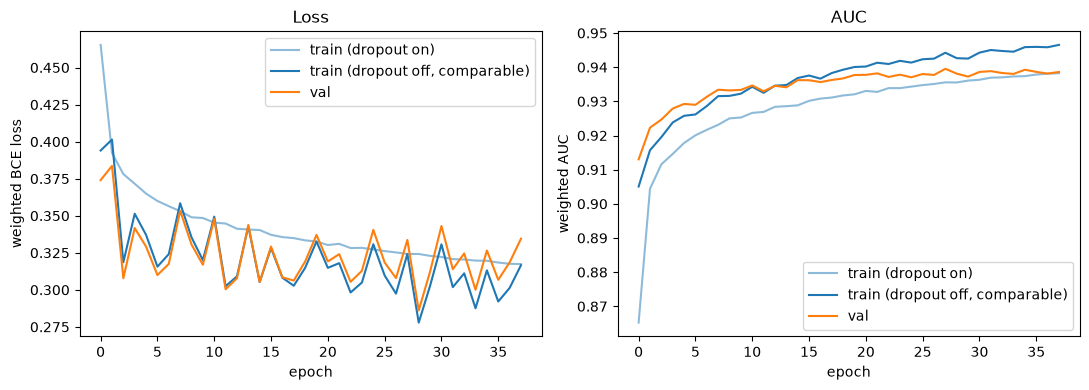

Final weighted AUC (POOLED across both channels): train=0.9442 val=0.9395
NOTE: a pooled number can be misleading if one channel is intrinsically cleaner than the other - see the per-channel breakdown right below, and don't draw conclusions before the 'Comparison Against Solo-Channel Baselines' section near the end.
Per-channel weighted val AUC: 1l2tau=0.9347 (69069 events) | 2l2tau=0.9575 (9497 events)
Saved plot -> PPSSP_2026/pnn_channel_combined/run2/plots/ChannelCombinedROC_PNN.png


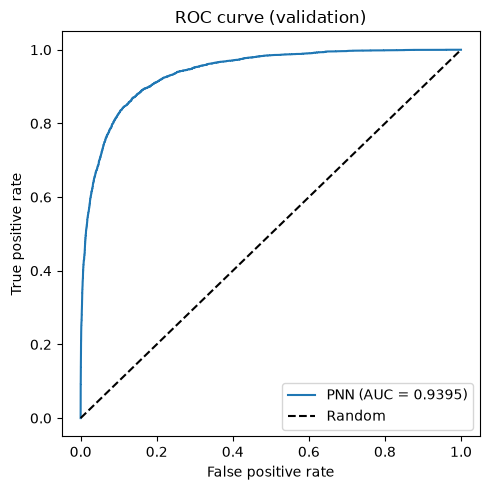

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()

PLOTS_DIR_COMBINED = BASE_DIR_COMBINED / "plots"
PLOTS_DIR_COMBINED.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOTS_DIR_COMBINED / "ChannelCombinedTrainingCurves_PNN.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_COMBINED / 'ChannelCombinedTrainingCurves_PNN.png'}")
plt.show()

model.eval()
with torch.no_grad():
    train_probs = torch.sigmoid(model(torch.tensor(X_train_scaled, dtype=torch.float32).to(DEVICE))).cpu().numpy()
    val_probs = torch.sigmoid(model(torch.tensor(X_val_scaled, dtype=torch.float32).to(DEVICE))).cpu().numpy()

auc_train = roc_auc_score(y_train, train_probs, sample_weight=np.abs(w_train))
auc_val = roc_auc_score(y_val, val_probs, sample_weight=w_val_fit)

print(f"Full (pre-pruning) baseline model - weighted AUC (POOLED across both channels): "
      f"train={auc_train:.4f} val={auc_val:.4f}")
print("NOTE: a pooled number can be misleading if one channel is intrinsically cleaner than the "
      "other - see the per-channel breakdown right below. This is the FULL baseline model; the "
      "'Correlation Pruning & Retraining'/'Top-15 Features Only' sections below retrain on smaller "
      "feature sets, and THOSE numbers (not these) are what carry through to the 'Comparison "
      "Against Solo-Channel Baselines' section near the end.")

# Per-channel val AUC breakdown of the FULL baseline model - each event is
# scored with its OWN true channel one-hot value here (no fixed-hypothesis
# trick), so this already shows how well the shared network does on each
# channel individually. Suffixed "_full" because the pruning stage below
# retrains smaller models and reassigns the plain val_auc_1l2tau/
# val_auc_2l2tau names to whichever model ends up FINAL (top-15).

is_1l2tau_val = (val_df["channel"] == "1l2tau").to_numpy()
is_2l2tau_val = (val_df["channel"] == "2l2tau").to_numpy()
val_auc_1l2tau_full = roc_auc_score(y_val[is_1l2tau_val], val_probs[is_1l2tau_val], sample_weight=w_val_fit[is_1l2tau_val])
val_auc_2l2tau_full = roc_auc_score(y_val[is_2l2tau_val], val_probs[is_2l2tau_val], sample_weight=w_val_fit[is_2l2tau_val])
print(f"Per-channel weighted val AUC (full baseline model): 1l2tau={val_auc_1l2tau_full:.4f} "
      f"({is_1l2tau_val.sum()} events) | 2l2tau={val_auc_2l2tau_full:.4f} ({is_2l2tau_val.sum()} events)")

fpr, tpr, _ = roc_curve(y_val, val_probs, sample_weight=w_val_fit)
fig = plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"PNN full baseline (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, full baseline model)")
plt.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR_COMBINED / "ChannelCombinedROC_PNN.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_COMBINED / 'ChannelCombinedROC_PNN.png'}")
plt.show()


## Feature Importance (Permutation)

Model-agnostic **permutation importance**: shuffle one feature's column
across events (destroying its relationship with the rest of the row) and
measure how much the weighted validation AUC drops. `is_1l2tau`/
`is_2l2tau` are included as ordinary entries in `MODEL_FEATURES` here - a
large drop when either is shuffled would confirm the network genuinely
uses the channel conditioning (rather than ignoring it and just relying on
the shared physics features).


Baseline weighted AUC: 0.9395


Saved plot -> PPSSP_2026/pnn_channel_combined/run2/plots/ChannelCombinedImportanceFull_PNN.png


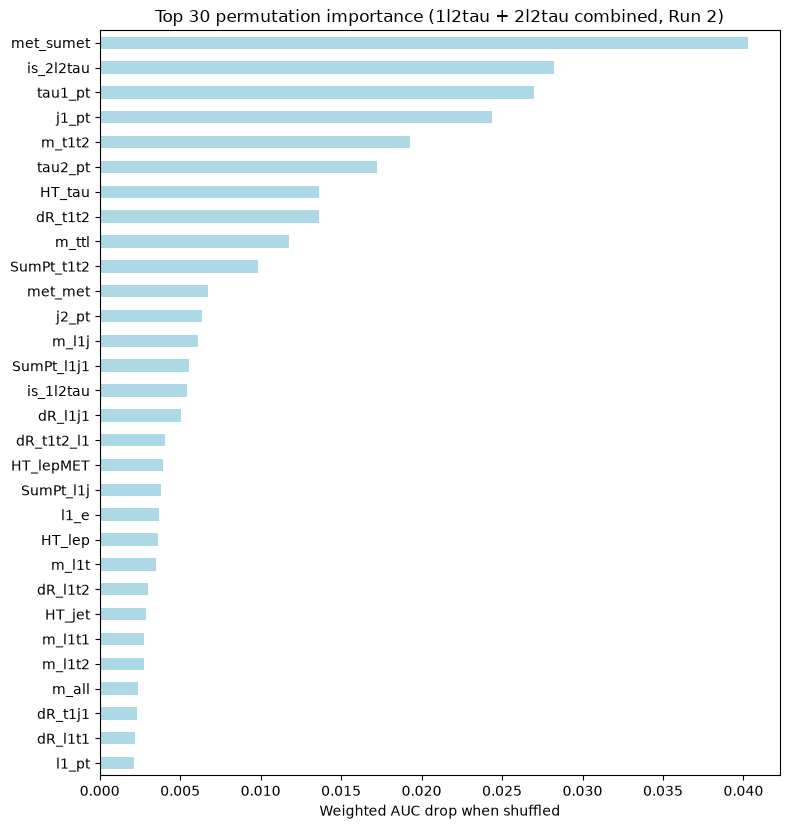

is_1l2tau: rank 15/63, AUC drop = 0.0054
is_2l2tau: rank 2/63, AUC drop = 0.0282


met_sumet     0.040259
is_2l2tau     0.028223
tau1_pt       0.027014
j1_pt         0.024358
m_t1t2        0.019260
tau2_pt       0.017258
HT_tau        0.013627
dR_t1t2       0.013605
m_ttl         0.011764
SumPt_t1t2    0.009847
met_met       0.006751
j2_pt         0.006380
m_l1j         0.006114
SumPt_l1j1    0.005545
is_1l2tau     0.005447
Name: auc_drop, dtype: float64

In [29]:
def permutation_importance(model, X, y, w, feature_names, n_repeats=5, random_state=RANDOM_STATE):

    """
    Model-agnostic feature importance: for each feature, shuffle its column
    across events `n_repeats` times and measure the average drop in weighted
    AUC relative to the unshuffled baseline. `X`, `y`, `w` must already be
    GPU-resident tensors with columns in the same order as `feature_names`
    (only the FIRST `len(feature_names)` columns of `X` are addressed - any
    trailing `__isnan` flag columns are intentionally left unreported).
    Returns a pandas Series (feature -> mean AUC drop), sorted descending.
    """

    rng = np.random.default_rng(random_state)
    model.eval()

    y_np = y.cpu().numpy()
    w_np = w.cpu().numpy()

    with torch.no_grad():
        baseline_probs = torch.sigmoid(model(X)).cpu().numpy()

    baseline_auc = roc_auc_score(y_np, baseline_probs, sample_weight=w_np)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []
    
    for i, feat in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            perm = torch.as_tensor(rng.permutation(X.shape[0]), device=X.device)
            X_perm = X.clone()
            X_perm[:, i] = X_perm[perm, i]

            with torch.no_grad():
                probs = torch.sigmoid(model(X_perm)).cpu().numpy()
            auc = roc_auc_score(y_np, probs, sample_weight=w_np)
            drops.append(baseline_auc - auc)

        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=feature_names, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by importance. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


importance = permutation_importance(model, X_val_t, y_val_t, w_val_t, MODEL_FEATURES, n_repeats=5)
plot_importance_bar(importance, top_n=30, title="Top 30 permutation importance (1l2tau + 2l2tau combined, Run 2)",
                     save_path=PLOTS_DIR_COMBINED / "ChannelCombinedImportanceFull_PNN.png")

for col in channel_cols:
    rank = int(importance.index.get_loc(col)) + 1
    print(f"{col}: rank {rank}/{len(importance)}, AUC drop = {importance[col]:.4f}")
importance.head(15)


## Correlation Pruning & Retraining

Mirrors the XGBoost master pipeline's (and the solo MLP/DNN/GNN notebooks')
correlation-pruning stage, so this combined-channel model is judged on the
same "full → pruned → top-15" ladder as its solo-channel baselines (see
the "Comparison Against Solo-Channel Baselines" section below): rank the
**physics** features by permutation importance, look at Pearson correlation
among the top candidates separately for signal and background, then walk
the ranked list keeping a feature only if it isn't too correlated
(`|corr| > 0.75`) with a more important feature already kept. The model is
then retrained from scratch on the decorrelated feature set, and again
restricted to just the top 15 physics features.

**Channel one-hot columns (`is_1l2tau`/`is_2l2tau`) are excluded from the
ranking/pruning candidate pool and the correlation walk, and are
UNCONDITIONALLY re-appended to every pruned/top-15 feature set.** They are
the entire point of this notebook (channel conditioning) - not a redundant
physics input - so it would defeat the purpose to let a generic
importance-ranked pruning step drop them just because they didn't crack
the top 30.


In [ ]:
TOP_N_IMPORTANCE = 30   # candidate pool size (physics features only), before correlation pruning
CORR_THRESH = 0.75      # |corr| above this -> considered redundant
N_KEEP = 20             # decorrelated physics features to keep in the main pruned model


def top_pairs(corr, thr=0.70):

    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""

    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):

    """
    Pearson correlation of `feats`, computed separately for each value of
    `group_col` (label 0/1 = background/signal here) - correlations
    genuinely differ between groups, so pruning must look at both, not just
    the pooled correlation.
    """

    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):

    """
    Side-by-side correlation heatmaps, one per entry in `corrs`/`names`. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="PuOr")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)

    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """

    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated physics features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


def subset_feature_tensors(feature_subset, all_features=MODEL_FEATURES):

    """
    Slice the already-scaled train/val/test numpy arrays down to
    `feature_subset` (columns picked by name, matching `all_features`'
    order) and move the result to GPU-resident tensors - the same shape
    train_model expects. TEST is only ever subset here for the one final
    "Held-Out Test Evaluation" cell near the end - never for training or
    model selection. `feature_subset` is expected to already include the
    channel one-hot columns where relevant (they're never dropped - see
    markdown above), so this function itself has no special-casing for them.
    """

    idx = [all_features.index(f) for f in feature_subset]
    X_train_sub_t = torch.tensor(X_train_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    X_val_sub_t = torch.tensor(X_val_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    X_test_sub_t = torch.tensor(X_test_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    return X_train_sub_t, X_val_sub_t, X_test_sub_t


In [ ]:
# ---- Correlation of the top-30 permutation-important PHYSICS features -----
# Channel one-hot columns are excluded from this ranking/pruning candidate
# pool (see markdown above) - they're always kept regardless of rank.
# Correlation is computed pooled across both channels (not per-channel),
# consistent with this notebook's "intersection-only" first-pass scope.

physics_importance = importance.drop(index=channel_cols)
top_feats = physics_importance.index[:TOP_N_IMPORTANCE].tolist()
corrs = grouped_correlations(data, top_feats, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs[1], corrs[0]], ["Signal", "Background"], top_feats,
    suptitle=f"1l2tau + 2l2tau combined (PNN) — correlation (top {TOP_N_IMPORTANCE} physics features)",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedCorrelationTop30_PNN.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs[0]).to_string())


In [ ]:
# ---- Correlation-based pruning to a decorrelated top-20 (physics only) -----
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.

corr_max = corrs[1].abs().combine(corrs[0].abs(), np.maximum)
PRUNED_FEATURES, dropped_features = prune_correlated(top_feats, corr_max, CORR_THRESH, N_KEEP)

# Channel one-hot columns are UNCONDITIONALLY re-appended (never pruned) -
# see the intro markdown and the section markdown above.
PRUNED_MODEL_FEATURES = PRUNED_FEATURES + channel_cols
print(f"\n+ {len(channel_cols)} channel one-hot columns (always retained, not part of the pruning "
      f"candidate pool): {channel_cols}")


In [ ]:
# ---- Retrain on the pruned feature set (physics pruned + channel one-hot) --
X_train_pruned_t, X_val_pruned_t, X_test_pruned_t = subset_feature_tensors(PRUNED_MODEL_FEATURES)

model_pruned, history_pruned, val_auc_pruned, train_auc_pruned, train_auc_eval_pruned = train_model(
    X_train_data=X_train_pruned_t, X_val_data=X_val_pruned_t,
)

print(f"Full model   ({len(MODEL_FEATURES):2d} features incl. channel one-hot): "
      f"train_auc_eval = {best_train_auc_eval:.4f} | val_auc (pooled) = {best_val_auc:.4f}")
print(f"Pruned model ({len(PRUNED_MODEL_FEATURES):2d} features incl. channel one-hot): "
      f"train_auc_eval = {train_auc_eval_pruned:.4f} | val_auc (pooled) = {val_auc_pruned:.4f}")

importance_pruned = permutation_importance(model_pruned, X_val_pruned_t, y_val_t, w_val_t, PRUNED_MODEL_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_pruned, top_n=len(PRUNED_MODEL_FEATURES),
    title=f"PNN permutation importance — pruned model ({len(PRUNED_MODEL_FEATURES)} features, "
          f"1l2tau + 2l2tau combined, Run 2)",
    color="lightsalmon",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedImportancePruned_PNN.png",
)

pruned_corrs = grouped_correlations(data, PRUNED_FEATURES, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs[1], pruned_corrs[0]], ["Signal", "Background"], PRUNED_FEATURES,
    suptitle=f"1l2tau + 2l2tau combined (PNN) — correlation (pruned, {len(PRUNED_FEATURES)} physics features)",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedCorrelationPruned_PNN.png",
)


## Top-15 Features Only

Same correlation-pruning walk over the same top-30 physics candidate pool,
but stopped once 15 decorrelated physics features are kept (plus the 2
channel one-hot columns, always retained - see the intro markdown and the
"Correlation Pruning & Retraining" section above), to see how much (if any)
weighted validation AUC is lost by cutting down to a much smaller,
easier-to-interpret feature set. **This top-15 model becomes the
notebook's FINAL model**, scored once on the held-out test set below -
matching the convention the solo XGBoost/MLP/DNN/GNN notebooks already use
for their own "Run 2" row in `model_summary_*.csv`, so the "Comparison
Against Solo-Channel Baselines" section stays an apples-to-apples,
top-15-vs-top-15 comparison.


In [ ]:
TOP15_FEATURES, dropped_top15 = prune_correlated(top_feats, corr_max, CORR_THRESH, n_keep=15)
TOP15_MODEL_FEATURES = TOP15_FEATURES + channel_cols

X_train_top15_t, X_val_top15_t, X_test_top15_t = subset_feature_tensors(TOP15_MODEL_FEATURES)

model_top15, history_top15, val_auc_top15, train_auc_top15, train_auc_eval_top15 = train_model(
    X_train_data=X_train_top15_t, X_val_data=X_val_top15_t,
)

importance_top15 = permutation_importance(model_top15, X_val_top15_t, y_val_t, w_val_t, TOP15_MODEL_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_top15, top_n=len(TOP15_MODEL_FEATURES),
    title=f"PNN permutation importance — top-15 model ({len(TOP15_MODEL_FEATURES)} features, "
          f"1l2tau + 2l2tau combined, Run 2)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedImportanceTop15_PNN.png",
)


def per_channel_val_auc(scores):
    """Weighted val AUC restricted to each channel's own events - the
    per-model version of the per-channel breakdown the intro markdown's
    'Evaluation: pooled AUC will lie' section insists on."""
    auc_1l2tau = roc_auc_score(y_val[is_1l2tau_val], scores[is_1l2tau_val], sample_weight=w_val_fit[is_1l2tau_val])
    auc_2l2tau = roc_auc_score(y_val[is_2l2tau_val], scores[is_2l2tau_val], sample_weight=w_val_fit[is_2l2tau_val])
    return auc_1l2tau, auc_2l2tau


model_pruned.eval()
with torch.no_grad():
    val_probs_pruned = torch.sigmoid(model_pruned(X_val_pruned_t)).cpu().numpy()
model_top15.eval()
with torch.no_grad():
    val_probs_top15 = torch.sigmoid(model_top15(X_val_top15_t)).cpu().numpy()

val_auc_1l2tau_pruned, val_auc_2l2tau_pruned = per_channel_val_auc(val_probs_pruned)
val_auc_1l2tau_top15, val_auc_2l2tau_top15 = per_channel_val_auc(val_probs_top15)

comparison = pd.DataFrame([
    {"model": f"Full ({len(MODEL_FEATURES)} features)", "train_auc_eval": best_train_auc_eval,
     "val_auc (pooled)": best_val_auc,
     "val_auc_1l2tau": val_auc_1l2tau_full, "val_auc_2l2tau": val_auc_2l2tau_full},
    {"model": f"Pruned ({len(PRUNED_MODEL_FEATURES)} features)", "train_auc_eval": train_auc_eval_pruned,
     "val_auc (pooled)": val_auc_pruned,
     "val_auc_1l2tau": val_auc_1l2tau_pruned, "val_auc_2l2tau": val_auc_2l2tau_pruned},
    {"model": f"Top-15 ({len(TOP15_MODEL_FEATURES)} features)", "train_auc_eval": train_auc_eval_top15,
     "val_auc (pooled)": val_auc_top15,
     "val_auc_1l2tau": val_auc_1l2tau_top15, "val_auc_2l2tau": val_auc_2l2tau_top15},
]).sort_values("val_auc (pooled)", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (pooled + per-channel; every row "
      f"includes all {len(channel_cols)} channel one-hot columns, never pruned):")
comparison


## Physics Figure of Merit

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region. This reports a max-Asimov-significance scan on
**VAL** (used for model/cut selection) for the **final model** - the
top-15 (physics) + channel one-hot model from the pruning walk above, the
most decorrelated/interpretable feature set, matching the convention the
solo XGBoost/MLP/DNN/GNN notebooks use for their own final model (see
`models_registry`/`best_name` below).

A genuinely blind estimate follows in the "Held-Out Test Evaluation" cell
below: the VAL-selected score cut is applied FROZEN to the never-before-seen
**TEST** partition (10% of the sample, held out by `make_3way_split` since
before preprocessing), reporting test AUC and test Z at that cut exactly
once.


In [ ]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """
    Max Asimov significance over score cuts. Uses SIGNED w_phys (expected
    yields, not |w_phys|). `min_bkg` guards the sparse high-score tail where
    Z is unstable/unphysical when B is tiny or negative. Treat Z as a
    RELATIVE metric for ranking models on the identical rows, not an
    absolute discovery number.
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None

    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))  # Asimov; -> S/sqrt(B) for S<<B
        if z > best_z:
            best_z, best_t = z, t

    return best_z, best_t


# ---- Score the FINAL model (top-15 physics features + channel one-hot) -
# the most decorrelated/interpretable feature set from the pruning walk
# above, matching the convention the solo XGBoost/MLP/DNN/GNN notebooks use
# for their own "Run 2" row (see the "Comparison Against Solo-Channel
# Baselines" section near the end).
models_registry = {
    f"Full ({len(MODEL_FEATURES)} features)": (model, X_val_t, X_test_t),
    f"Pruned ({len(PRUNED_MODEL_FEATURES)} features)": (model_pruned, X_val_pruned_t, X_test_pruned_t),
    f"Top-15 ({len(TOP15_MODEL_FEATURES)} features)": (model_top15, X_val_top15_t, X_test_top15_t),
}
best_name = f"Top-15 ({len(TOP15_MODEL_FEATURES)} features)"

final_model, X_val_final_t, X_test_final_t = models_registry[best_name]
FINAL_MODEL_FEATURES = TOP15_MODEL_FEATURES  # keep the name<->feature-list mapping explicit

final_model.eval()
with torch.no_grad():
    val_scores = torch.sigmoid(final_model(X_val_final_t)).cpu().numpy()

z_val, thr_val = significance_scan(y_val, val_scores, w_val)  # signed w_phys - expected yields

# These now become the canonical "val_auc_1l2tau"/"val_auc_2l2tau" names the
# rest of the notebook (Held-Out Test Evaluation, Parameterized Inference
# Validation, Comparison Against Solo-Channel Baselines, Final Summary,
# Export) already reads - i.e. everything downstream reports the FINAL
# (top-15) model, not the full baseline model from the "Evaluation" section
# above (that one is preserved under the "_full" suffix).

final_val_auc = comparison.loc[comparison["model"] == best_name, "val_auc (pooled)"].iloc[0]
final_train_auc_eval = comparison.loc[comparison["model"] == best_name, "train_auc_eval"].iloc[0]
val_auc_1l2tau = comparison.loc[comparison["model"] == best_name, "val_auc_1l2tau"].iloc[0]
val_auc_2l2tau = comparison.loc[comparison["model"] == best_name, "val_auc_2l2tau"].iloc[0]

print(f"Final model: {best_name}")
print(f"Weighted val AUC (pooled) = {final_val_auc:.4f}  |  1l2tau = {val_auc_1l2tau:.4f}  |  "
      f"2l2tau = {val_auc_2l2tau:.4f}")
print(f"Max Asimov Z (val, pooled) = {z_val:.3f} at score cut = {thr_val:.4f}")


Weighted val AUC = 0.9395
Max Asimov Z (val) = 0.035 at score cut = 0.9868


### Held-Out Test Evaluation

`X_test_final_t`/`y_test`/`w_test` have not participated in anything above -
not the imputation/scaler fit, not correlation pruning, not the score-cut
selection just above. This is the one place they are read: the final model
(top-15 physics features + channel one-hot, `best_name` above) is scored
once, and the VAL-selected score cut is applied frozen (not re-scanned).


In [ ]:
# ---- HELD-OUT TEST EVALUATION — scored EXACTLY ONCE ------------------------
final_model.eval()
with torch.no_grad():
    test_scores = torch.sigmoid(final_model(X_test_final_t)).cpu().numpy()

auc_test = roc_auc_score(y_test, test_scores, sample_weight=w_test_fit)

S_test = w_test[(test_scores >= thr_val) & (y_test == 1)].sum()
B_test = w_test[(test_scores >= thr_val) & (y_test == 0)].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"Final model: {best_name}")
print(f"Weighted AUC (POOLED): val = {auc_val:.4f}  |  test (held-out, scored once) = {auc_test:.4f}")
print(f"At the VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test:.2f} | test B = {B_test:.2f} | test Z = {z_test:.3f}  (val Z was {z_val:.3f})")

# Per-channel test AUC + Z breakdown - each event already carries its OWN
# true channel one-hot value in X_test_final_t (no fixed-hypothesis trick
# needed here), so this is simply the shared network's performance
# restricted to each channel's held-out rows, at the SAME frozen
# val-selected cut.
is_1l2tau_test = (test_df["channel"] == "1l2tau").to_numpy()
is_2l2tau_test = (test_df["channel"] == "2l2tau").to_numpy()
auc_test_1l2tau = roc_auc_score(y_test[is_1l2tau_test], test_scores[is_1l2tau_test], sample_weight=w_test_fit[is_1l2tau_test])
auc_test_2l2tau = roc_auc_score(y_test[is_2l2tau_test], test_scores[is_2l2tau_test], sample_weight=w_test_fit[is_2l2tau_test])
print(f"Per-channel weighted test AUC: 1l2tau={auc_test_1l2tau:.4f} ({is_1l2tau_test.sum()} events) | "
      f"2l2tau={auc_test_2l2tau:.4f} ({is_2l2tau_test.sum()} events)")

z_test_1l2tau, z_test_2l2tau = np.nan, np.nan
for cell, mask in [("1l2tau", is_1l2tau_test), ("2l2tau", is_2l2tau_test)]:
    S_c = w_test[mask & (test_scores >= thr_val) & (y_test == 1)].sum()
    B_c = w_test[mask & (test_scores >= thr_val) & (y_test == 0)].sum()
    z_c = np.sqrt(2 * ((S_c + B_c) * np.log(1 + S_c / B_c) - S_c)) if (S_c > 0 and B_c > 0) else np.nan
    print(f"  [{cell}] test S = {S_c:.2f} | test B = {B_c:.2f} | test Z = {z_c:.3f}  (same frozen val cut)")
    if cell == "1l2tau":
        z_test_1l2tau = z_c
    else:
        z_test_2l2tau = z_c


Weighted AUC (POOLED): val = 0.9395  |  test (held-out, scored once) = 0.9402
At the VAL-selected score cut = 0.9868 (frozen, NOT re-scanned on test):
  test S = 0.04 | test B = 1.35 | test Z = 0.036  (val Z was 0.035)
Per-channel weighted test AUC: 1l2tau=0.9357 (69069 events) | 2l2tau=0.9566 (9497 events)
  [1l2tau] test S = 0.03 | test B = 0.76 | test Z = 0.035  (same frozen val cut)
  [2l2tau] test S = 0.01 | test B = 0.59 | test Z = 0.016  (same frozen val cut)


## Parameterized Inference Validation

Runs against the **final model** (top-15 physics features + channel
one-hot, `best_name`/`FINAL_MODEL_FEATURES` from the pruning stage above),
not the full baseline model - the channel one-hot columns are always
present in every candidate model (see the "Correlation Pruning &
Retraining" section), so this check is meaningful regardless of which
candidate ends up final.

Two checks here, not one:

1. **Sensitivity pre-check** - does the network respond to the channel
   flag AT ALL? With only 2 of ~70 input columns devoted to it, it's a real
   risk that the network just ignores them. Fixing `is_1l2tau`/`is_2l2tau`
   to each hypothesis for the SAME validation batch and measuring the mean
   shift in predicted probability is a direct, necessary (not sufficient)
   test of this - if it's ~0, conditioning at the input layer isn't working
   and per-layer conditioning/FiLM should be tried next (see the model
   markdown above).
2. **Own-hypothesis check** - the standard conditional-training validation:
   for every **validation** event (test stays touched only once, above),
   the one-hot columns are overwritten to `(1,0)` (1l2tau-mode) and `(0,1)`
   (2l2tau-mode), re-scoring the SAME trained network both times (no
   retraining), and each setting's weighted AUC is measured restricted to
   that channel's own events (signal + background). A well-behaved model
   should show its highest AUC for 1l2tau events when evaluated at
   1l2tau-mode, and its highest AUC for 2l2tau events at 2l2tau-mode - i.e.
   the diagonal of the cross-table below should dominate. This is the same
   morphing-style check the original PNN literature uses, adapted from a
   continuous/randomized parameter to a real, deterministic one - there is
   no interpolation claim being made here, just "does the network actually
   use the channel information it was given".



Sensitivity check: mean |score(1l2tau-mode) - score(2l2tau-mode)| over ALL val events = 0.1122
event_subset  1l2tau events  2l2tau events
scored_at                                 
1l2tau-mode          0.9347         0.9554
2l2tau-mode          0.9304         0.9575

1l2tau events: AUC at own hypothesis = 0.9347  vs  at 2l2tau hypothesis = 0.9304
2l2tau events: AUC at own hypothesis = 0.9575  vs  at 1l2tau hypothesis = 0.9554
Channel-conditioning check PASSED: each channel scores best when the network is queried at its own hypothesis.
Saved plot -> PPSSP_2026/pnn_channel_combined/run2/plots/ChannelCombinedConditioningCheck_PNN.png


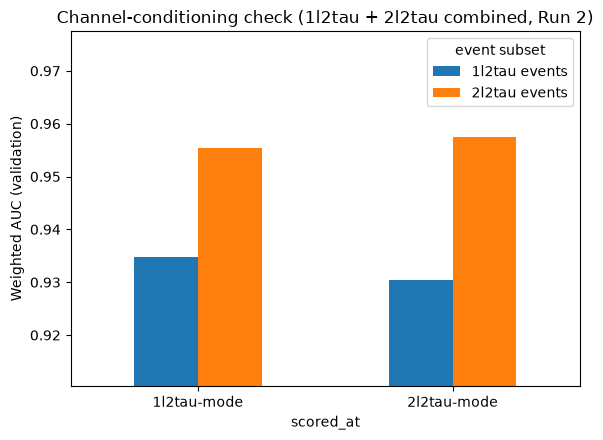

In [ ]:
def score_at_fixed_channel(model, X_scaled, channel_col_idx, one_hot_value):

    """
    Re-score `model` on `X_scaled` (a GPU tensor already containing the
    physics + one-hot channel + flag columns) after OVERWRITING the two
    channel columns with a single fixed one-hot vector for every row - no
    retraining, just changes which channel hypothesis the shared network
    is asked to evaluate under. `channel_col_idx` = (idx_is_1l2tau,
    idx_is_2l2tau); `one_hot_value` = (v1, v2), e.g. (1.0, 0.0) for
    "1l2tau-mode".
    """

    X_fixed = X_scaled.clone()
    for idx, val in zip(channel_col_idx, one_hot_value):
        X_fixed[:, idx] = val
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X_fixed)).cpu().numpy()


# Indices into FINAL_MODEL_FEATURES (the FINAL/top-15 model's own feature
# list, not the full model's MODEL_FEATURES) - the two lists put the channel
# one-hot columns at different positions, since pruning shrinks the physics
# feature count in front of them.
channel_col_idx = tuple(FINAL_MODEL_FEATURES.index(c) for c in channel_cols)

# ---- 1. Sensitivity pre-check: does the network respond to the flag AT ALL? ---
scores_as_1l2tau = score_at_fixed_channel(final_model, X_val_final_t, channel_col_idx, (1.0, 0.0))
scores_as_2l2tau = score_at_fixed_channel(final_model, X_val_final_t, channel_col_idx, (0.0, 1.0))
mean_abs_shift = float(np.mean(np.abs(scores_as_1l2tau - scores_as_2l2tau)))
print(f"Sensitivity check: mean |score(1l2tau-mode) - score(2l2tau-mode)| over ALL val events = {mean_abs_shift:.4f}")
if mean_abs_shift < 1e-3:
    print("  WARNING: the network barely responds to the channel flag - it may be getting ignored "
          "(consider conditioning at every hidden layer, or FiLM, instead of input-concat only).")

# ---- 2. Own-hypothesis check -----------------------------------------------
is_1l2tau_val = (val_df["channel"] == "1l2tau").to_numpy()
is_2l2tau_val = (val_df["channel"] == "2l2tau").to_numpy()

rows = []
for hypothesis_name, one_hot_value in [("1l2tau-mode", (1.0, 0.0)), ("2l2tau-mode", (0.0, 1.0))]:
    scores_fixed = score_at_fixed_channel(final_model, X_val_final_t, channel_col_idx, one_hot_value)
    for channel_name, channel_mask in [("1l2tau events", is_1l2tau_val), ("2l2tau events", is_2l2tau_val)]:
        auc = roc_auc_score(y_val[channel_mask], scores_fixed[channel_mask], sample_weight=w_val_fit[channel_mask])
        rows.append({"scored_at": hypothesis_name, "event_subset": channel_name, "weighted_auc": auc})

pnn_validation_df = pd.DataFrame(rows).pivot(index="scored_at", columns="event_subset", values="weighted_auc")
pnn_validation_df = pnn_validation_df[["1l2tau events", "2l2tau events"]]
print(pnn_validation_df.to_string(float_format=lambda x: f"{x:.4f}"))

diag_1l2tau = pnn_validation_df.loc["1l2tau-mode", "1l2tau events"]
offdiag_1l2tau = pnn_validation_df.loc["2l2tau-mode", "1l2tau events"]
diag_2l2tau = pnn_validation_df.loc["2l2tau-mode", "2l2tau events"]
offdiag_2l2tau = pnn_validation_df.loc["1l2tau-mode", "2l2tau events"]

print(f"\n1l2tau events: AUC at own hypothesis = {diag_1l2tau:.4f}  vs  at 2l2tau hypothesis = {offdiag_1l2tau:.4f}")
print(f"2l2tau events: AUC at own hypothesis = {diag_2l2tau:.4f}  vs  at 1l2tau hypothesis = {offdiag_2l2tau:.4f}")

if diag_1l2tau >= offdiag_1l2tau and diag_2l2tau >= offdiag_2l2tau:
    print("Channel-conditioning check PASSED: each channel scores best when the network is queried at its own hypothesis.")
else:
    print("Channel-conditioning check: at least one channel does NOT peak at its own hypothesis - "
          "inspect further before trusting the conditioning.")

fig, ax = plt.subplots(figsize=(6, 4.5))
pnn_validation_df.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Weighted AUC (validation)")
ax.set_title(f"Channel-conditioning check ({best_name}, 1l2tau + 2l2tau combined, Run 2)")
ax.set_ylim(max(0.5, pnn_validation_df.to_numpy().min() - 0.02), pnn_validation_df.to_numpy().max() + 0.02)
ax.legend(title="event subset")
plt.tight_layout()
pnn_plot_path = PLOTS_DIR_COMBINED / "ChannelCombinedConditioningCheck_PNN.png"
fig.savefig(pnn_plot_path, dpi=150)
print(f"Saved plot -> {pnn_plot_path}")
plt.show()


## Comparison Against Solo-Channel Baselines

Pooled/global numbers can be misleading here - if one channel is
intrinsically cleaner than the other, pooling raises the headline AUC even
if the combined model got WORSE in a specific channel. The only comparison
that actually matters: **for each channel, does this combined model beat
that channel's own solo-trained models (XGBoost/MLP/DNN/GNN, Run 2 track)
in THAT channel** - loaded from the `model_summary_*.csv` files each of
those notebooks already exports (the same files `ModelComparison.ipynb`
reads). Gracefully skips any model/channel combination whose CSV hasn't
been produced yet (that notebook not run).

**Apples-to-apples note:** each solo notebook's exported "Run 2" row is
itself that notebook's own FINAL model (top-15, correlation-pruned
features, not its full baseline - see each notebook's own pruning
section), and `auc_test_1l2tau`/`auc_test_2l2tau` used below now come from
THIS notebook's final (top-15 + channel one-hot) model too, so this is a
final-vs-final comparison, not full-vs-pruned.



In [33]:
SOLO_MODELS = ["xgboost", "mlp", "dnn", "gnn"]

baseline_rows = []
for channel_name in ["1l2tau", "2l2tau"]:
    for model_name in SOLO_MODELS:
        path = Path(f"PPSSP_2026/{channel_name}/summary_plots/model_summary_{model_name}.csv")
        if not path.exists():
            print(f"  (skipping {channel_name}/{model_name}: {path} not found yet)")
            continue
        baseline_df_one = pd.read_csv(path)
        run2_row = baseline_df_one[baseline_df_one["track"].astype(str).str.contains("Run 2", na=False)]
        if run2_row.empty:
            print(f"  (skipping {channel_name}/{model_name}: no 'Run 2' track row in {path})")
            continue
        baseline_rows.append({
            "channel": channel_name, "model": model_name,
            "test_auc": float(run2_row["test_auc"].iloc[0]),
        })

combined_channel_results = {"1l2tau": auc_test_1l2tau, "2l2tau": auc_test_2l2tau}

if baseline_rows:
    baseline_df = pd.DataFrame(baseline_rows)
    print(baseline_df.to_string(index=False))

    print("\nCombined-channel model vs. each channel's own solo baselines (test AUC):")
    for channel_name in ["1l2tau", "2l2tau"]:
        combined_auc = combined_channel_results[channel_name]
        sub = baseline_df[baseline_df["channel"] == channel_name]
        if sub.empty:
            print(f"  {channel_name}: no solo baselines found yet to compare against")
            continue
        beats_all = bool((combined_auc >= sub["test_auc"]).all())
        best_solo = sub.loc[sub["test_auc"].idxmax()]
        print(f"  {channel_name}: combined test_auc = {combined_auc:.4f}  |  "
              f"best solo baseline = {best_solo['model']} ({best_solo['test_auc']:.4f})  |  "
              f"{'BEATS all solo baselines' if beats_all else 'DOES NOT beat all solo baselines'}")
else:
    print("No solo-baseline summary CSVs found yet - run the XGBoost/MLP/DNN/GNN notebooks "
          "for Run 2 (both channels) to populate this comparison.")


  (skipping 2l2tau/gnn: PPSSP_2026/2l2tau/summary_plots/model_summary_gnn.csv not found yet)
channel   model  test_auc
 1l2tau xgboost  0.937122
 1l2tau     mlp  0.948052
 1l2tau     dnn  0.934655
 1l2tau     gnn  0.916594
 2l2tau xgboost  0.973966
 2l2tau     mlp  0.961474
 2l2tau     dnn  0.972081

Combined-channel model vs. each channel's own solo baselines (test AUC):
  1l2tau: combined test_auc = 0.9357  |  best solo baseline = mlp (0.9481)  |  DOES NOT beat all solo baselines
  2l2tau: combined test_auc = 0.9566  |  best solo baseline = xgboost (0.9740)  |  DOES NOT beat all solo baselines


Saved plot -> PPSSP_2026/pnn_channel_combined/run2/plots/ChannelCombinedVsSoloBaselines_PNN.png


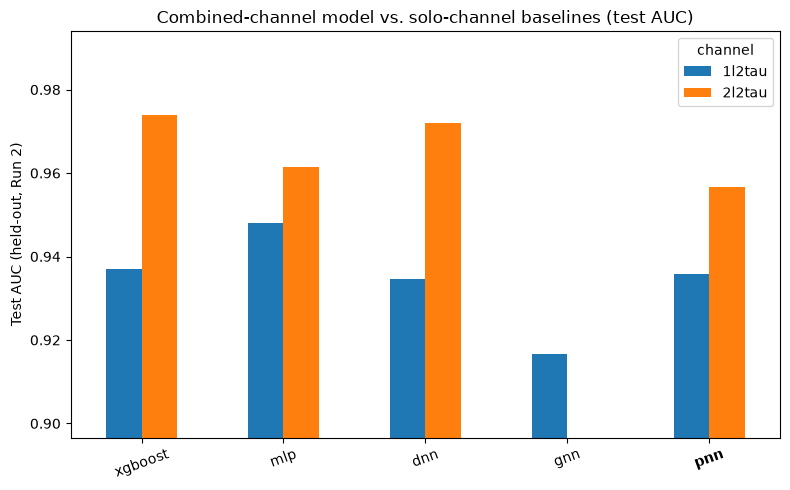

In [38]:
# Grouped bar chart: solo baselines (from `baseline_rows` above) plus this
# combined-channel model's own per-channel test AUC, side by side per model,
# grouped by channel - the visual version of the "BEATS/DOES NOT beat"
# printout above.

plot_rows = list(baseline_rows)
for channel_name, combined_auc in combined_channel_results.items():
    plot_rows.append({"channel": channel_name, "model": "pnn", "test_auc": combined_auc})

if plot_rows:
    plot_df = pd.DataFrame(plot_rows)
    pivot = plot_df.pivot(index="model", columns="channel", values="test_auc")

    model_order = [m for m in SOLO_MODELS + ["pnn"] if m in pivot.index]
    pivot = pivot.reindex(model_order)
    channel_order = [c for c in ["1l2tau", "2l2tau"] if c in pivot.columns]
    pivot = pivot[channel_order]

    fig, ax = plt.subplots(figsize=(8, 5))
    pivot.plot.bar(ax=ax, rot=20)
    ax.set_ylabel("Test AUC (held-out, Run 2)")
    ax.set_xlabel("")
    ax.set_title("Combined-channel model vs. solo-channel baselines (test AUC)")
    finite_vals = pivot.to_numpy()[np.isfinite(pivot.to_numpy())]
    if finite_vals.size:
        ax.set_ylim(max(0.5, finite_vals.min() - 0.02), finite_vals.max() + 0.02)
    ax.legend(title="channel")

    # Bold the "combined-channel" x-tick label so it stands out among the solo baselines.
    for label in ax.get_xticklabels():
        if label.get_text() == "pnn":
            label.set_fontweight("bold")

    plt.tight_layout()
    baseline_plot_path = PLOTS_DIR_COMBINED / "ChannelCombinedVsSoloBaselines_PNN.png"
    fig.savefig(baseline_plot_path, dpi=150)
    print(f"Saved plot -> {baseline_plot_path}")
    plt.show()
else:
    print("Nothing to plot yet - no solo-baseline CSVs found and no combined-channel results computed.")


## Sanity Checks & Final Summary

In [ ]:
# ---- Sanity checks --------------------------------------------------------

assert np.isfinite(X_train_scaled).all() and np.isfinite(X_val_scaled).all() and np.isfinite(X_test_scaled).all(), \
    "NaN/inf reached the model input"

# Determinism check: re-seeding immediately before each of two short training
# runs should give an EXACT match, proving set_seed()/
# use_deterministic_algorithms(True) actually pin every source of randomness
# (weight init, dropout masks, batch shuffling). Uses a cheap config (small
# model, 5 epochs, full feature set) purely to keep this check fast - it
# tests the training procedure itself, independent of which pruning stage
# ends up "final".

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)

assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

# ---- Final summary ---------------------------------------------------------
# "model" name deliberately says "conditional multi-channel" rather than
# "PNN" - see intro markdown for why that distinction matters here (no
# randomized/interpolatable parameter, channel is a real observed property
# of every event). Reports the FINAL model (best_name, top-15 physics
# features + channel one-hot) - NOT the full baseline model from the
# "Evaluation" section, which is preserved separately under the "_full"
# suffix (val_auc_1l2tau_full/val_auc_2l2tau_full) and in the `comparison`
# table above.

summary = pd.DataFrame([{
    "model": f"Conditional multi-channel NN — {best_name} (one-hot: is_1l2tau, is_2l2tau, always retained)",
    "train_auc_eval": final_train_auc_eval,
    "val_auc (pooled)": final_val_auc,
    "val_auc_1l2tau": val_auc_1l2tau,
    "val_auc_2l2tau": val_auc_2l2tau,
    "max_asimov_Z (val, pooled)": z_val,
    "test_auc (pooled, held-out, scored once)": auc_test,
    "test_auc_1l2tau (held-out)": auc_test_1l2tau,
    "test_auc_2l2tau (held-out)": auc_test_2l2tau,
    "test_Z_at_val_cut (pooled, held-out)": z_test,
    "test_Z_1l2tau_at_val_cut (held-out)": z_test_1l2tau,
    "test_Z_2l2tau_at_val_cut (held-out)": z_test_2l2tau,
    "own_hypothesis_auc (1l2tau, 2l2tau)": (diag_1l2tau, diag_2l2tau),
    "sensitivity_mean_abs_score_shift": mean_abs_shift,
}])

print("\nFinal summary (1l2tau + 2l2tau combined, Run 2) - see the `comparison` table (full/pruned/"
      "top-15) and per-channel breakdown above, and the solo-baseline comparison below, before "
      "drawing conclusions from the pooled numbers:")
print(summary.to_string(index=False))
summary


Determinism check passed: two re-seeded runs give identical val_auc = 0.917386

Final summary (1l2tau + 2l2tau combined, Run 2) - see per-channel breakdown and solo-baseline comparison above before drawing conclusions from the pooled numbers:
                                                       model  train_auc_eval  val_auc (pooled)  val_auc_1l2tau  val_auc_2l2tau  max_asimov_Z (val, pooled)  test_auc (pooled, held-out, scored once)  test_auc_1l2tau (held-out)  test_auc_2l2tau (held-out)  test_Z_at_val_cut (pooled, held-out)  test_Z_1l2tau_at_val_cut (held-out)  test_Z_2l2tau_at_val_cut (held-out)      own_hypothesis_auc (1l2tau, 2l2tau)  sensitivity_mean_abs_score_shift
Conditional multi-channel NN (one-hot: is_1l2tau, is_2l2tau)         0.94423          0.939535        0.934734        0.957473                     0.03494                                   0.94022                    0.935707                    0.956575                              0.036473                           

,model,train_auc_eval,val_auc (pooled),val_auc_1l2tau,val_auc_2l2tau,"max_asimov_Z (val, pooled)","test_auc (pooled, held-out, scored once)",test_auc_1l2tau (held-out),test_auc_2l2tau (held-out),"test_Z_at_val_cut (pooled, held-out)",test_Z_1l2tau_at_val_cut (held-out),test_Z_2l2tau_at_val_cut (held-out),"own_hypothesis_auc (1l2tau, 2l2tau)",sensitivity_mean_abs_score_shift
0,Conditional multi-channel NN (one-hot: is_1l2t...,0.94423,0.939535,0.934734,0.957473,0.03494,0.94022,0.935707,0.956575,0.036473,0.034761,0.015703,"(0.9347342190624364, 0.9574725087813635)",0.112185


## Export Summary for Cross-Notebook Comparison

Written for `ModelComparison.ipynb` to load - same schema
(`channel`/`model`/`track`/`val_auc`/`test_auc`) as the XGBoost/MLP/DNN/GNN
exports. Since this single trained network covers BOTH channels, it writes
TWO rows (one per channel, each channel's own val/test AUC subset from the
per-channel breakdowns above, NOT the pooled numbers) to
`PPSSP_2026/<channel>/summary_plots/model_summary_pnn.csv` for each channel
- exactly where `ModelComparison.ipynb` already looks for a `pnn` entry per
channel, so no changes are needed there. The `model` label there stays
`"pnn"` for consistency with the other notebooks' file naming, even though
this notebook's own markdown calls it conditional multi-channel training.


In [35]:
model_summary_rows = [
    {"channel": "1l2tau", "model": "pnn", "track": "Channel-Combined",
     "val_auc": val_auc_1l2tau, "test_auc": auc_test_1l2tau},
    {"channel": "2l2tau", "model": "pnn", "track": "Channel-Combined",
     "val_auc": val_auc_2l2tau, "test_auc": auc_test_2l2tau},
]
model_summary_df = pd.DataFrame(model_summary_rows)

for channel_name, row_df in model_summary_df.groupby("channel"):
    out_dir = Path(f"PPSSP_2026/{channel_name}/summary_plots")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "model_summary_pnn.csv"
    row_df.to_csv(out_path, index=False)
    print(f"Saved model comparison summary -> {out_path}")

model_summary_df


Saved model comparison summary -> PPSSP_2026/1l2tau/summary_plots/model_summary_pnn.csv
Saved model comparison summary -> PPSSP_2026/2l2tau/summary_plots/model_summary_pnn.csv


,channel,model,track,val_auc,test_auc
0,1l2tau,pnn,Channel-Combined,0.934734,0.935707
1,2l2tau,pnn,Channel-Combined,0.957473,0.956575
